In [ ]:
# --- Setup: make the `ecp` support package available -----------------
# Colab opens a single notebook and installs nothing, so fetch `ecp` from
# the public repo if it isn't importable yet. On Binder/local it is already
# installed, so this cell is a fast no-op there.
try:
    import ecp  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "git+https://github.com/ramador09/elementary-computational-physics-public@main"],
        check=True,
    )


# 4.1 The Electronic Band Structure of Silicon

<!-- One H1 per notebook ("# <number> <Title>"): it sets the sidebar entry,
     breadcrumb, browser tab, and search result. The branded banner below is
     generated by the shared `ecp` package. -->

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Volume IV — Electronic Structure",
    number="4.1",
    title="The Electronic Band Structure of Silicon",
    blurb="From a real Quantum ESPRESSO calculation: Bloch states and the "
    "Brillouin zone, the band structure of silicon along L–Γ–X, its indirect gap, "
    "and the famous failure of density-functional theory to get that gap right.",
    difficulty="intermediate",
    estimate="75–105 min",
    source="FS 2023 · Lecture 5 (band theory of crystals)",
)

<ECP header: 2799 chars of HTML>

## Notebook overview

Why does silicon carry current the way it does, absorb the light it does, and sit
at the heart of every chip? The answer is its **band structure**: the map of
allowed electron energies as a function of crystal momentum. In a periodic solid
the electronic states organise into bands, and the gap between the filled and
empty ones decides whether a material is a metal, a semiconductor, or an insulator.
Computing that map is the central task of electronic-structure theory.

This is the band-theory exercise of Lecture 5, and unlike the earlier volumes it is
**code-essential**: density-functional theory cannot be reimplemented in a
notebook, and the real skill is running the calculation and reading its output. So
we work with the genuine article. We show the Quantum ESPRESSO input deck the
course used for silicon, parse the **real committed output** of that
density-functional calculation, plot the band structure along the high-symmetry
path L–Γ–X, and read off the indirect gap. Then we confront the result with
experiment, and meet the most famous systematic error in the field: the
density-functional **band-gap problem**.

> **Provenance.** This notebook develops **Lecture 5** of the course (band theory
> of crystals), an exercise **originally designed by Dr. Carlo Pignedoli**, here
> redesigned and rephrased by the author. The band structure is parsed from the *real* output of the
> course's Quantum ESPRESSO calculation of silicon (the committed
> `exercise-5/TASK_3/done/SI.xml`), and the input is the course's own `scf.in`. No
> part of the electronic structure is recomputed or invented; we read and analyse
> the actual DFT result. The full course credit is in the footer.

> **Reading a validation.** Each exercise closes with a check against an
> independent fact: an electron count, the known position of silicon's band
> extrema, the measured gap. A ✗ flags a mismatch to track down, not a verdict; a
> ✓ is strong evidence, not proof.

> **Scope.** Energies are in electronvolts (the QE output is converted from
> Hartree). For the solid-state background see Ashcroft & Mermin
> {cite}`ashcroft-mermin` and Martin {cite}`martin-electronic`; for the code,
> Quantum ESPRESSO {cite}`giannozzi2009`; for the functional, PBE {cite}`pbe1996`.

## Theory in brief

### Bloch's theorem and bands

In a crystal the potential is periodic, $V(\mathbf r+\mathbf R)=V(\mathbf r)$ for
every lattice vector $\mathbf R$. **Bloch's theorem** then says the electronic
eigenstates can be labelled by a **crystal momentum** $\mathbf k$ and a band index
$n$, and take the form

```{math}
:label: eq-bloch
\psi_{n\mathbf k}(\mathbf r) = e^{i\mathbf k\cdot\mathbf r}\,u_{n\mathbf k}(\mathbf r),
\qquad u_{n\mathbf k}(\mathbf r+\mathbf R)=u_{n\mathbf k}(\mathbf r),
```

with energies $E_n(\mathbf k)$. Because $\mathbf k$ and $\mathbf k+\mathbf G$
(for a reciprocal-lattice vector $\mathbf G$) give the same state, every distinct
$\mathbf k$ lives in one **Brillouin zone**. The function $E_n(\mathbf k)$, plotted
along straight lines between the high-symmetry points of that zone, is the **band
structure**. For the face-centred-cubic lattice of silicon those points include
$\Gamma$ (the zone centre), $X$ (a face centre), and $L$ (a corner).

### Filling, gaps, and silicon

Each band holds two electrons per unit cell (spin up and down) at each $\mathbf k$.
A material with exactly enough electrons to fill some bands completely, leaving the
rest empty, has a **band gap** between the highest filled state (the valence-band
maximum, VBM) and the lowest empty one (the conduction-band minimum, CBM), and is a
semiconductor or insulator; a material with a partly filled band is a metal.
Silicon crystallises in the diamond structure (an fcc lattice with a two-atom
basis) and contributes $4\times2=8$ valence electrons per cell, so **four bands
fill** and a gap opens above them.

The gap is **indirect**: the VBM and the CBM sit at *different* crystal momenta, so
promoting an electron across it requires a change in $\mathbf k$ (supplied by a
phonon), which is why silicon is a poor light emitter. The smallest *direct* gap,
at $\Gamma$, is much larger.

### Density-functional theory, and what it gets wrong

The calculation solves the Kohn-Sham equations of **density-functional theory**
(DFT): a set of effective single-particle equations whose density reproduces the
interacting electron density. Quantum ESPRESSO expands the Kohn-Sham orbitals in
plane waves and uses pseudopotentials for the core electrons. DFT is remarkably
good for ground-state energies and structures, but the **Kohn-Sham eigenvalue gap
systematically underestimates the true gap**, often by a factor of two: the
band-gap problem, a consequence of the missing derivative discontinuity in
approximate exchange-correlation functionals {cite}`perdew-levy-1983`. We will see
it directly.

---
## Setup

In [2]:
import os
import xml.etree.ElementTree as ET

import numpy as np
import matplotlib.pyplot as plt

from ecp import validate

INK, AMBER, SOFT = "#16213e", "#c0851a", "#46506b"
HARTREE_EV = 27.211386                   # QE writes energies in Hartree


def data_file(name):
    """Locate a shipped data file, from the repo root (CI) or the notebook dir (Colab).

    Parameters
    ----------
    name : str
        File name (or relative path) under a ``data`` directory.

    Returns
    -------
    str
        The first existing path found.

    Raises
    ------
    FileNotFoundError
        If the file is not found under any candidate base.
    """
    for base in ("data", os.path.join("notebooks", "04-electronic-structure", "data")):
        path = os.path.join(base, name)
        if os.path.exists(path):
            return path
    raise FileNotFoundError(name)

## Exercise 1 — The crystal and the DFT calculation

Every band structure begins with a ground-state (self-consistent-field)
calculation that finds the electron density and the Kohn-Sham potential. The
course's Quantum ESPRESSO input for silicon fixes the crystal (an fcc lattice,
`ibrav=2`, with the diamond two-atom basis), the plane-wave cutoff (`ecutwfc=40`
Ry), the PBE pseudopotential, and a $6\times6\times6$ k-mesh for the density:

```text
&SYSTEM
  ibrav = 2,  celldm(1) = 10.26,   ! fcc lattice, lattice parameter in bohr
  nat = 2,  ntyp = 1,              ! two Si atoms per cell (diamond basis)
  ecutwfc = 40.0,  ecutrho = 300.0 ! plane-wave kinetic-energy cutoffs (Ry)
/
ATOMIC_SPECIES
  Si  28.0855  Si.pbe-n-rrkjus_psl.1.0.0.UPF
ATOMIC_POSITIONS {alat}
  Si  0.00 0.00 0.00
  Si  0.25 0.25 0.25
K_POINTS automatic
  6 6 6  1 1 1
```

A second run (`calculation='bands'`) then evaluates the Kohn-Sham eigenvalues along
the path **L–Γ–X**, which is what we plot. The full SCF deck ships with this
notebook: {download}`si-scf.in <data/si-scf.in>`.

**Part a)** Read the lattice parameter from the input. **Part b)** Confirm the
crystal is the expected two-atom fcc cell.

In [3]:
# (solution hidden on the public site)


### Validation 1 — the silicon cell

The deck must describe two silicon atoms in a cell with the known lattice constant
of silicon, $a=5.43\,$Å, i.e. `celldm(1)` $\approx 10.26\,$bohr.

In [4]:
validate.check(n_atoms == 2, "the cell holds two Si atoms (diamond basis)", f"nat = {n_atoms}")
validate.close(celldm * 0.529177, 5.43, "lattice constant matches silicon (5.43 Å)", rtol=2e-2)

✓  the cell holds two Si atoms (diamond basis)   [nat = 2]
✓  lattice constant matches silicon (5.43 Å)   [got 5.4306 vs expected 5.43 (rtol=0.02)]


True

## Exercise 2 — Reading the real DFT output

Quantum ESPRESSO writes its results to an XML file. The band-structure run stores,
for every k-point on the path, the list of Kohn-Sham eigenvalues, along with the
number of electrons and the Fermi energy. We parse that file directly: this is the
actual output of the course's calculation, not a recomputation.

**Part a)** Implement `read_qe_bands` to extract the k-points, eigenvalues (in eV),
Fermi energy, and electron count. **Part b)** Confirm the electron count implies
four filled bands.

In [5]:
# (solution hidden on the public site)


### Validation 2 — the parse is consistent with silicon

The output must report eight valence electrons (so four filled bands), with at
least one empty band above them, and a sensible number of k-points along the path.

In [6]:
validate.check(
    n_elec == 8 and n_occ == 4 and n_bands > n_occ and n_kpts > 50,
    "the DFT output describes silicon: 8 electrons, 4 filled bands",
    f"{n_elec:.0f} electrons → {n_occ} filled bands; {n_bands} bands at {n_kpts} k-points",
)

✓  the DFT output describes silicon: 8 electrons, 4 filled bands   [8 electrons → 4 filled bands; 8 bands at 100 k-points]


True

## Exercise 3 — The band structure of silicon

Now plot it. We build a one-dimensional coordinate that measures distance travelled
along the L–Γ–X path, place a tick at each high-symmetry point, and draw every band
$E_n(\mathbf k)$ with energies referenced to the valence-band maximum (the
conventional zero). Four bands sit below the gap, the rest above; the shape of
those curves *is* the electronic structure of silicon.

**Part a)** Build the k-path distance and locate Γ. **Part b)** Plot all bands
relative to the VBM, marking L, Γ, X.

findfont: Failed to find font weight 600, now using 700.


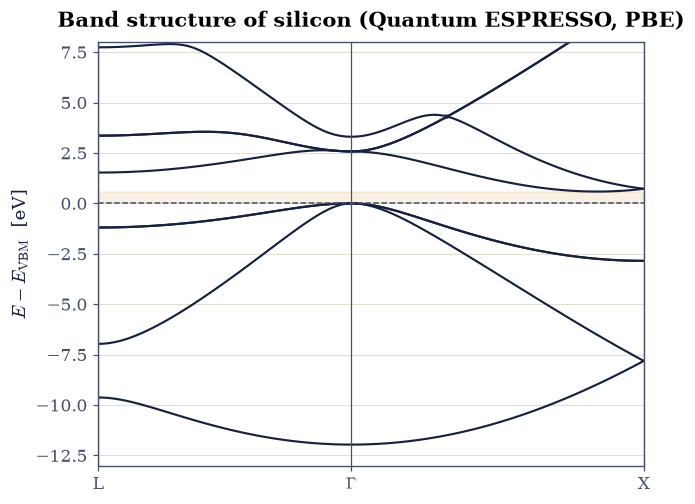

In [7]:
# (solution hidden on the public site)


### Validation 3 — four valence bands below the gap

At every k-point along the path the four valence bands must lie at or below the
VBM (energy $\le 0$), the basic structure of a filled-shell semiconductor.

In [8]:
validate.check(
    np.all(E[:, :n_occ] <= 1e-6),
    "the four valence bands lie at or below the valence-band maximum everywhere",
    f"max valence energy relative to VBM = {E[:, :n_occ].max():.3f} eV",
)

✓  the four valence bands lie at or below the valence-band maximum everywhere   [max valence energy relative to VBM = 0.000 eV]


True

## Exercise 4 — The indirect band gap

Read the gap off the bands. The valence-band maximum is the highest point of the
fourth band; the conduction-band minimum is the lowest point of the fifth. For
silicon the VBM sits at $\Gamma$ and the CBM lies about $0.85$ of the way from
$\Gamma$ to X, so the two are at different crystal momenta and the gap is
**indirect**. The smallest *direct* gap, both extrema taken at $\Gamma$, is far
larger, which confirms the indirect character.

**Part a)** Find the VBM, the CBM, and their k-points. **Part b)** Compute the
indirect gap and the direct gap at $\Gamma$.

In [9]:
# (solution hidden on the public site)


VBM = 6.226 eV at Γ;  CBM = 6.810 eV at ~0.83 of Γ→X
indirect gap = 0.584 eV;  direct gap at Γ = 2.574 eV


### Validation 4 — silicon's indirect gap

The PBE calculation must reproduce the qualitative band structure of silicon: a VBM
at $\Gamma$, a CBM away from $\Gamma$ along $\Gamma$–X (so an *indirect* gap), and a
much larger direct gap at $\Gamma$. The indirect gap is the well-known PBE value of
about $0.6\,$eV.

In [10]:
validate.check(vbm_at_gamma, "the valence-band maximum is at Γ", f"VBM index {i_vbm}, Γ index {gamma_idx}")
validate.check(
    gap_direct_gamma > 1.5 * gap_indirect and 0.4 < cbm_frac < 1.0,
    "the gap is indirect: CBM lies along Γ–X, direct gap at Γ is much larger",
    f"direct@Γ {gap_direct_gamma:.2f} eV vs indirect {gap_indirect:.2f} eV; CBM at {cbm_frac:.2f} of Γ→X",
)
validate.close(gap_indirect, 0.6, "the PBE indirect gap is about 0.6 eV", atol=0.1)

✓  the valence-band maximum is at Γ   [VBM index 45, Γ index 45]
✓  the gap is indirect: CBM lies along Γ–X, direct gap at Γ is much larger   [direct@Γ 2.57 eV vs indirect 0.58 eV; CBM at 0.83 of Γ→X]
✓  the PBE indirect gap is about 0.6 eV   [got 0.583652 vs expected 0.6 (rtol=1e-06)]


True

## Exercise 5 — The band-gap problem

Silicon's measured band gap is $1.17\,$eV. The PBE calculation gives barely half of
that. This is not a mistake in the run or a lack of convergence: it is the
**band-gap problem** of density-functional theory. The Kohn-Sham eigenvalues are
auxiliary quantities chosen to reproduce the *density*, not the energies to add or
remove an electron, and approximate exchange-correlation functionals miss a
*derivative discontinuity* that the true gap contains {cite}`perdew-levy-1983`. The
upshot is a systematic underestimate, often near a factor of two, that more
expensive methods (hybrid functionals, $GW$) are needed to repair.

**Part a)** Compare the computed gap to experiment. **Part b)** Confirm the
underestimate.

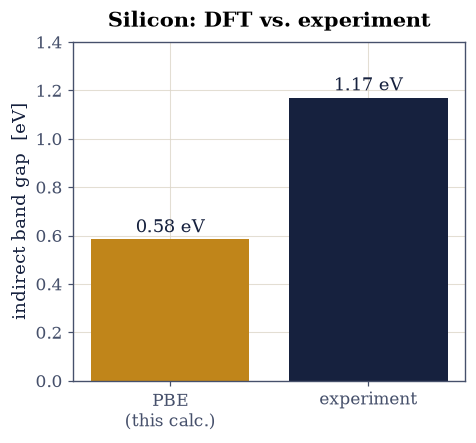

In [11]:
# (solution hidden on the public site)


### Validation 5 — DFT underestimates the gap

The computed gap must fall well short of the experimental $1.17\,$eV, the
signature of the Kohn-Sham band-gap problem.

In [12]:
validate.check(
    gap_indirect < 0.7 * gap_experiment,
    "the PBE gap substantially underestimates the experimental value",
    f"PBE {gap_indirect:.2f} eV vs experiment {gap_experiment:.2f} eV ({gap_indirect/gap_experiment*100:.0f}%)",
)

✓  the PBE gap substantially underestimates the experimental value   [PBE 0.58 eV vs experiment 1.17 eV (50%)]


True

## Notebook summary

We read the course's real Quantum ESPRESSO output for silicon and turned it into
the band structure along $L$–$\Gamma$–$X$. The valence-band maximum sits at
$\Gamma$ while the conduction-band minimum lies toward $X$, making the gap
**indirect**, the feature that shapes silicon's optical absorption and its role in
electronics. We also met the band-gap problem: the Kohn–Sham gap from semilocal DFT
underestimates the measured $1.17\,$eV, a known and instructive limitation of the
method rather than a numerical error.

## Outlook

- **Fixing the gap.** Hybrid functionals (HSE) mix in exact exchange and roughly
  halve the error; the $GW$ approximation computes the true quasiparticle gap and
  gets silicon within a tenth of an eV. Both cost far more than PBE.
- **The density of states.** Integrate the bands over the whole Brillouin zone (not
  just the path) to get $g(E)$, which is what optical and transport measurements
  actually probe.
- **Other crystals.** The course also ran silicon carbide and a graphene
  nanoribbon; rerunning this analysis on them shows a wider gap (SiC) and the
  one-dimensional bands of the ribbon.
- **Effective masses.** The curvature of the bands at the VBM and CBM,
  $1/m^\* = \hbar^{-2}\,d^2E/dk^2$, sets the mobility of electrons and holes; fit a
  parabola near each extremum to extract it.

### References

```{bibliography}
:filter: docname in docnames
```

In [13]:
from ecp.style import footer

footer()

<ECP header: 1690 chars of HTML>